In [37]:
##zadanie 1
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import suptitle
from sklearn.neighbors import KNeighborsClassifier
from sklearn.utils import resample
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split


data = load_wine()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42)

n_bootstrap = 1000
accuracies = []

for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_train, y_train, random_state=i)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_boot, y_boot)

    acc = knn.score(X_test, y_test)
    accuracies.append(acc)


accuracies[:10]


[0.75,
 0.6944444444444444,
 0.7222222222222222,
 0.7222222222222222,
 0.7777777777777778,
 0.7222222222222222,
 0.6944444444444444,
 0.8055555555555556,
 0.6666666666666666,
 0.75]

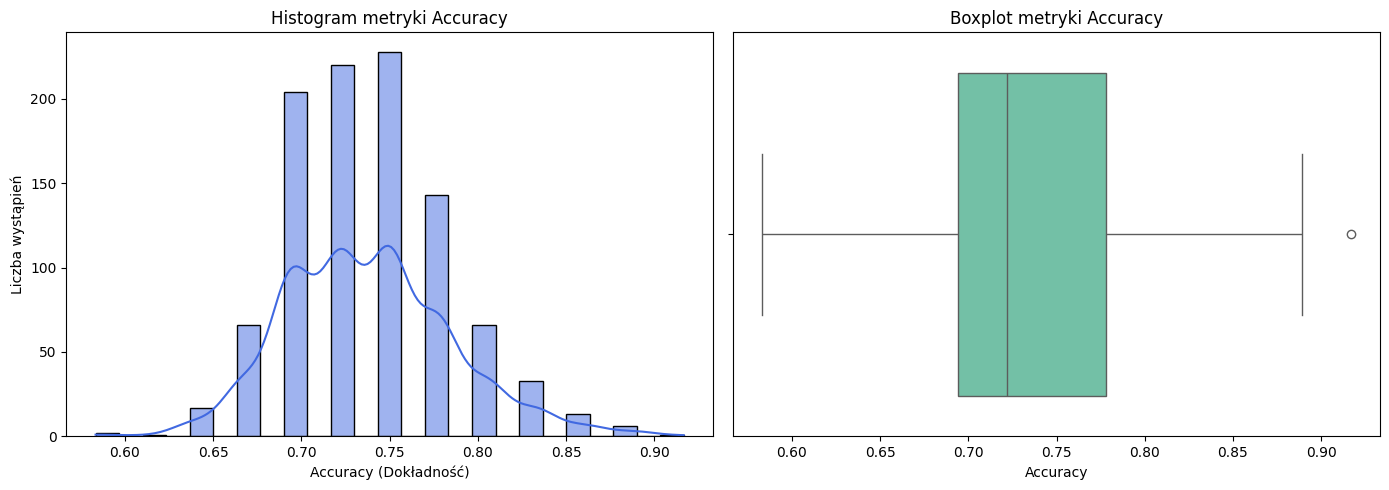

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(accuracies, bins=25, kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Histogram metryki Accuracy')
axes[0].set_xlabel('Accuracy (Dokładność)')
axes[0].set_ylabel('Liczba wystąpień')


sns.boxplot(x=accuracies, color='mediumaquamarine', ax=axes[1])
axes[1].set_title('Boxplot metryki Accuracy')
axes[1].set_xlabel('Accuracy')

plt.tight_layout()
plt.show()

In [39]:
lower_bound = np.percentile(accuracies, 2.5)
upper_bound = np.percentile(accuracies, 97.5)

print("--- Wyniki Eksperymentu Bootstrapowego ---")
print(f"Średnia dokładność (Accuracy): {np.mean(accuracies):.4f}")
print(f"95% Przedział ufności: od {lower_bound:.4f} do {upper_bound:.4f}")

--- Wyniki Eksperymentu Bootstrapowego ---
Średnia dokładność (Accuracy): 0.7375
95% Przedział ufności: od 0.6667 do 0.8333


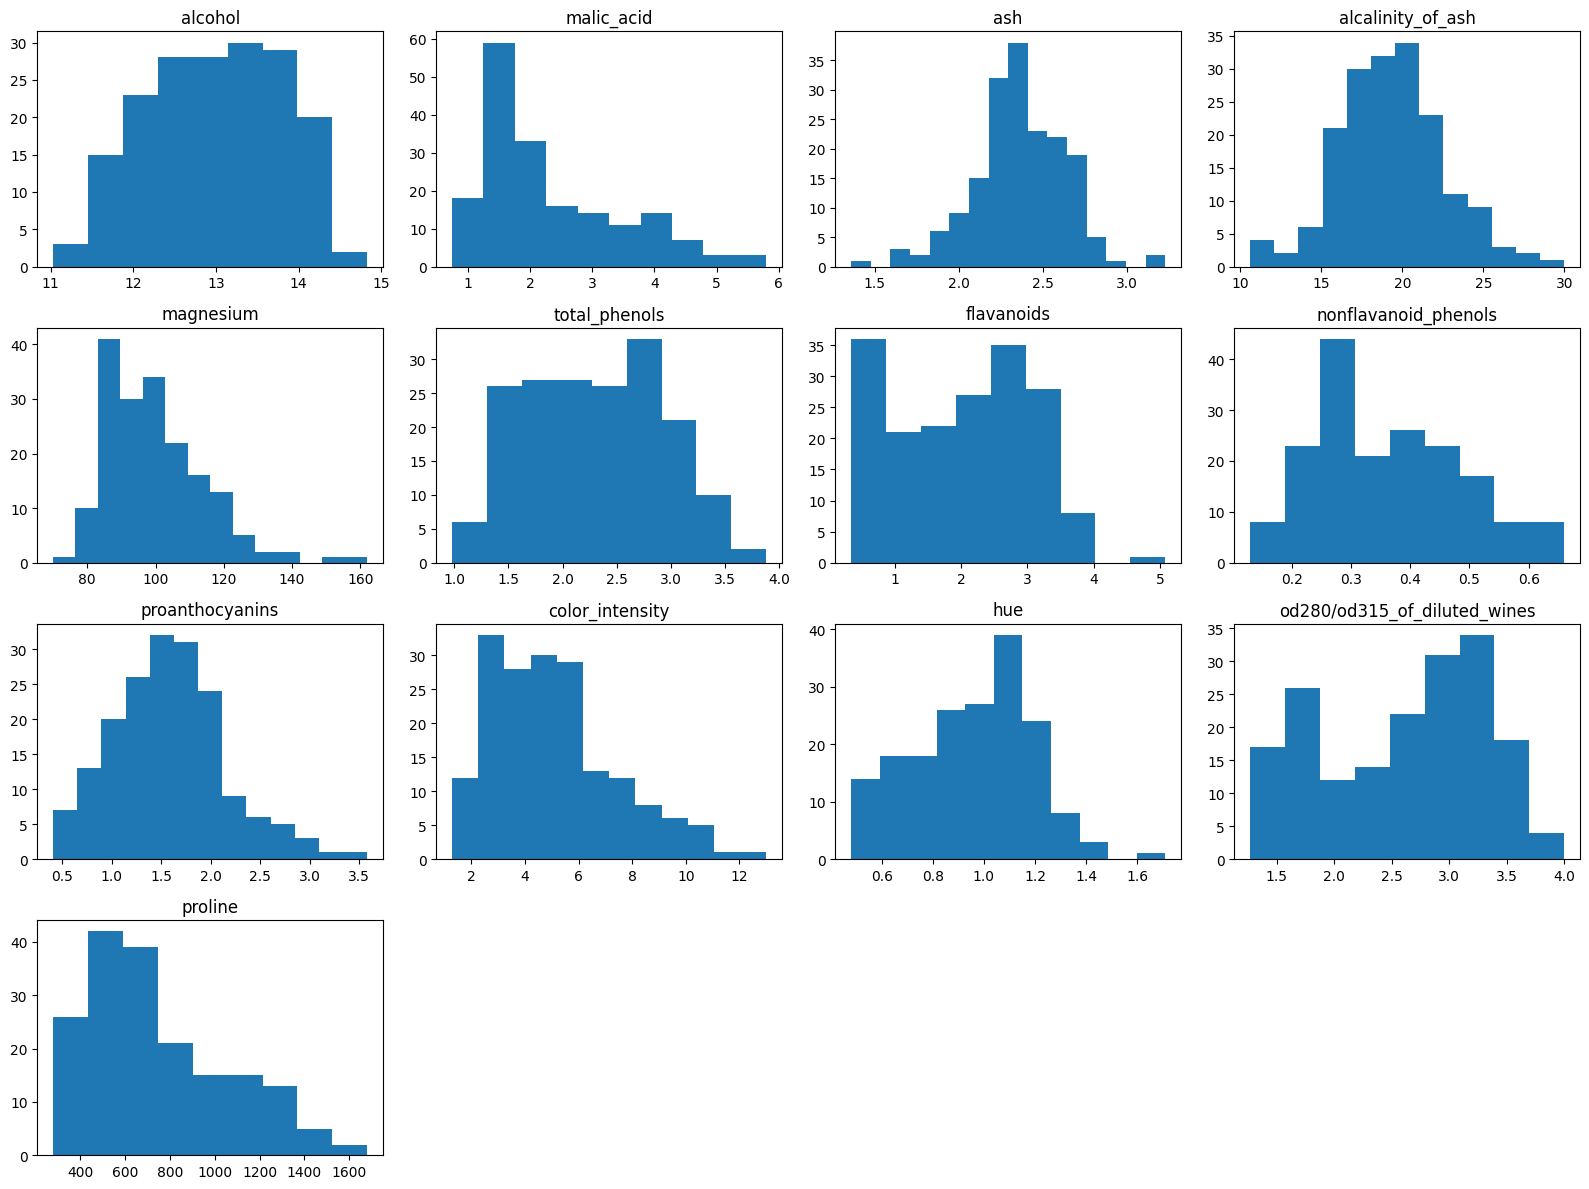

In [45]:
##zadanie 2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

X = data.data


fig, axes = plt.subplots(4,4, figsize=(16,12))
axes = axes.flatten()

for i in range(len(data.feature_names)):
    axes[i].hist(X[:, i], bins='auto')
    axes[i].set_title(data.feature_names[i])

for i in range(len(data.feature_names), len(axes)):
    fig.delaxes(axes[i])


plt.tight_layout()
plt.show()

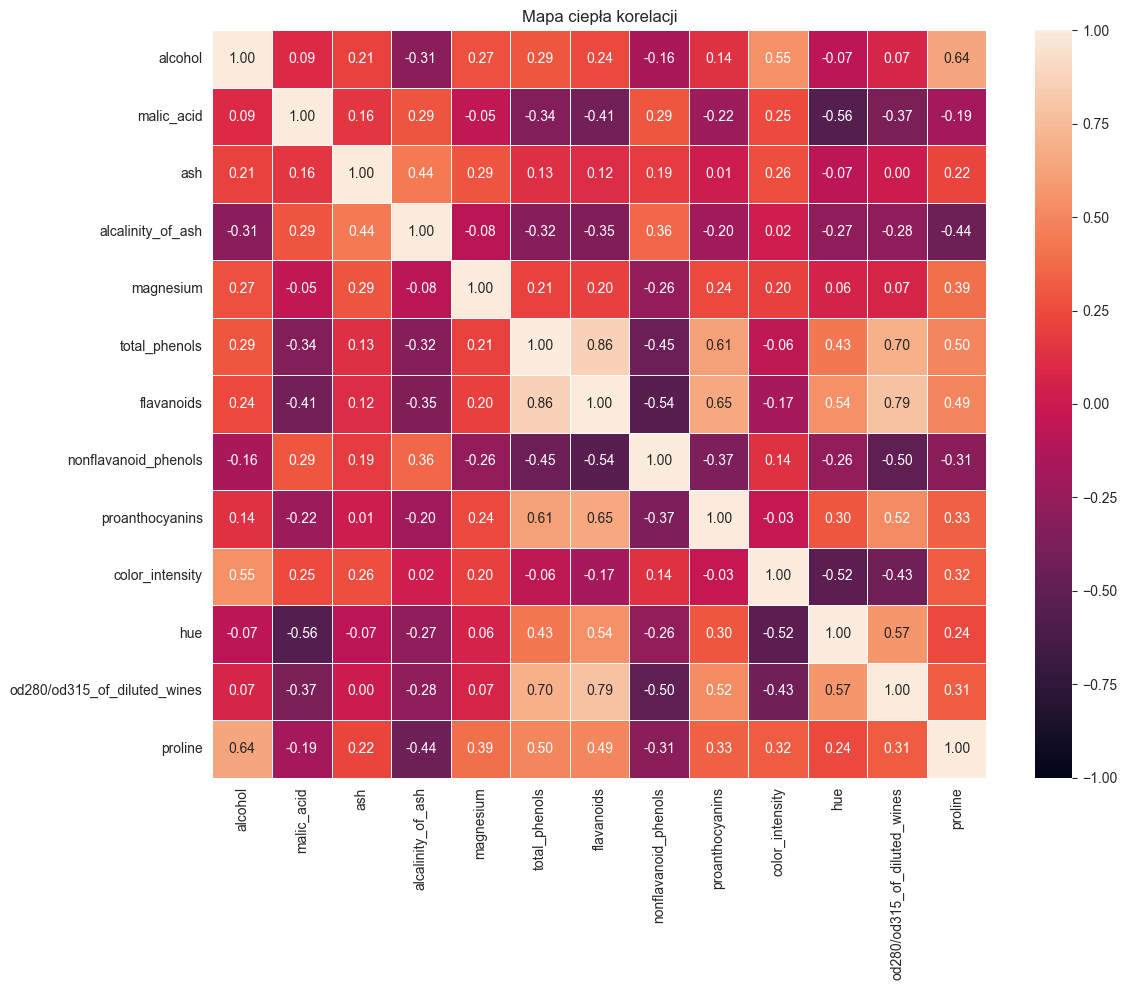

In [4]:
##zadanie 3

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

data = load_wine()
df_wine = pd.DataFrame(data.data, columns=data.feature_names)

corr_matrix = df_wine.corr(method='pearson')

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            vmin=-1, vmax=1,
            linewidths=0.5)

plt.title('Mapa ciepła korelacji')
plt.tight_layout()
plt.show()

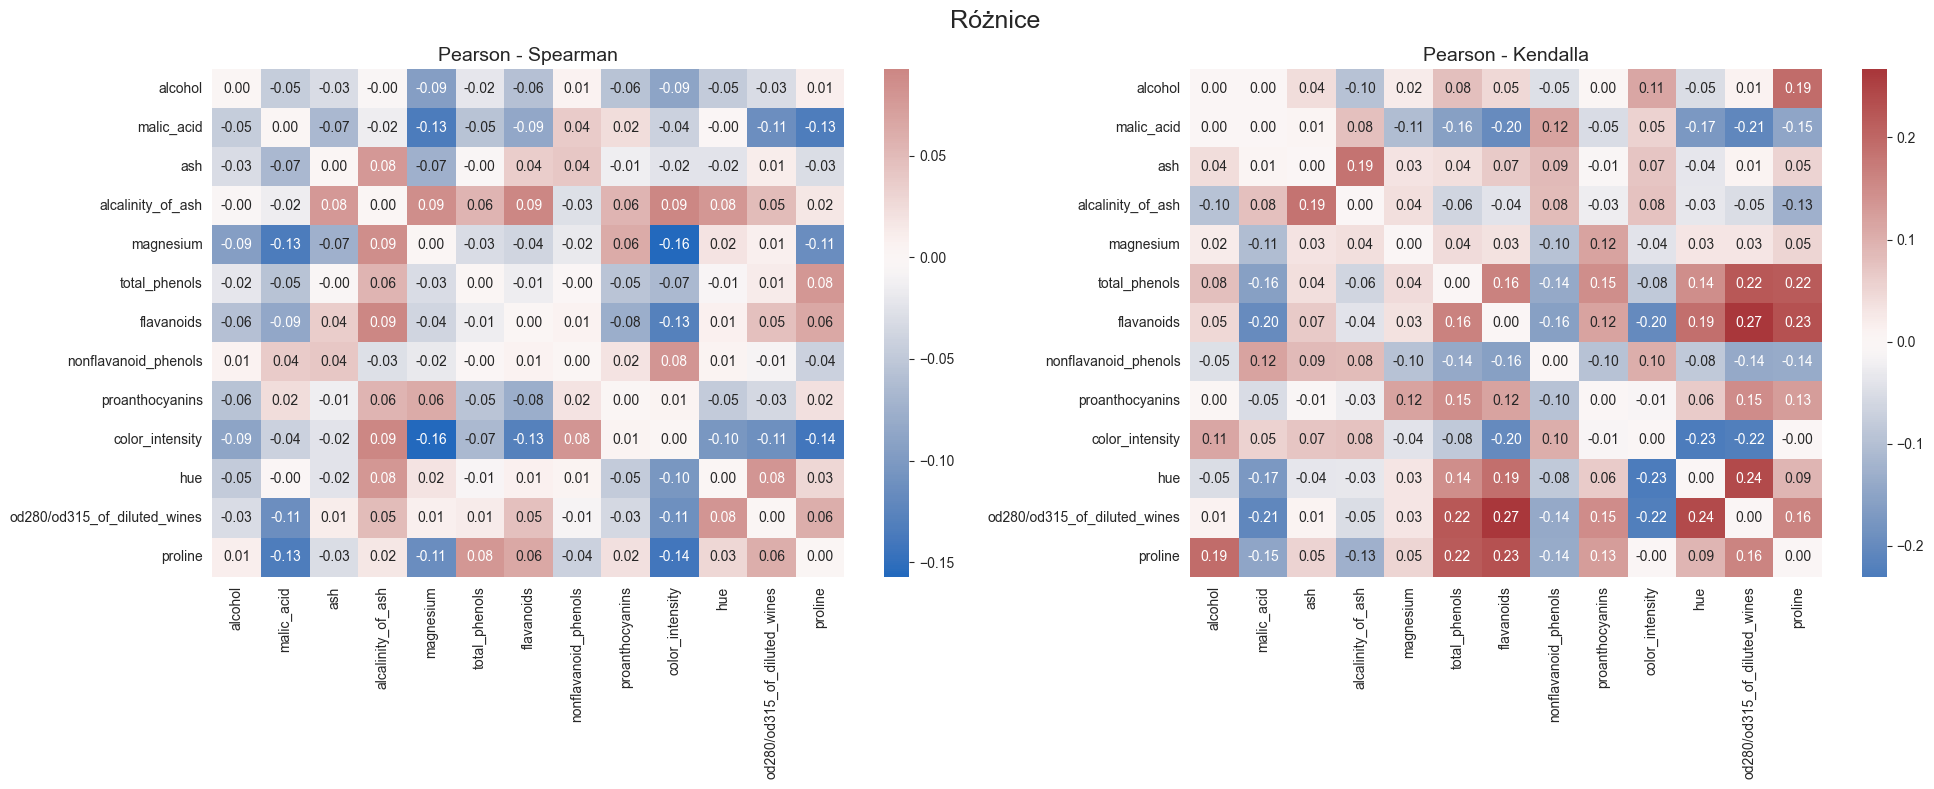

In [5]:
##zadanie 4

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine

data = load_wine()
df_wine = pd.DataFrame(data.data, columns=data.feature_names)

corr_pearson = df_wine.corr(method='pearson').to_numpy()
corr_spearman = df_wine.corr(method='spearman').to_numpy()
corr_kendall = df_wine.corr(method='kendall').to_numpy()


diff_pearson_spearman = corr_pearson - corr_spearman
diff_pearson_kendall = corr_pearson - corr_kendall

feature_names = df_wine.columns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Różnice", fontsize=18)

sns.heatmap(diff_pearson_spearman,
            annot=True, fmt=".2f", cmap="vlag", center=0,
            xticklabels=feature_names, yticklabels=feature_names,
            ax=axes[0])
axes[0].set_title('Pearson - Spearman', fontsize=14)

sns.heatmap(diff_pearson_kendall,
            annot=True, fmt=".2f", cmap="vlag", center=0,
            xticklabels=feature_names, yticklabels=feature_names,
            ax=axes[1])
axes[1].set_title('Pearson - Kendalla', fontsize=14)

plt.tight_layout()
plt.show()


## Tak mozna stwierdzic taką zależnośc. Cechy nienormalne: skrajne wartości zawyżają/zaniżają wynik korelacji Pearsona. Spearman i Kendall ignorują wielkość skrajnych odchyleń. Cechy o rozkładzie normalnym: Nie ma tam ekstremalnych wartości, więc dają bardzo zbliżone wyniki.

In [9]:
##zadanie 5

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

data = load_wine()
df_wine = pd.DataFrame(data.data, columns=data.feature_names)
df_wine['Class'] = data.target

spearman_corr = df_wine.corr(method='spearman')['Class'].drop('Class')

spearman_corr_sorted = spearman_corr.reindex(spearman_corr.abs().sort_values(ascending=False).index)

print("Korelacja Spearmana z atrybutem class:")
for feature, value in spearman_corr_sorted.items():
    print(f"{feature:30}: {value:.4f}")

features_to_drop = spearman_corr_sorted.index[-3:].tolist()
print(f"\nBez 3 najsłabszych cech: {features_to_drop}")

X_reduced = df_wine.drop(columns=features_to_drop + ['Class']).values
y = df_wine['Class'].values

X_train_red, X_test_red, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

n_bootstrap = 1000
accuracies_reduced = []

for i in range(n_bootstrap):
    X_boot, y_boot = resample(X_train_red, y_train, random_state=i)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_boot, y_boot)

    acc = knn.score(X_test_red, y_test)
    accuracies_reduced.append(acc)

mean_acc = np.mean(accuracies_reduced)
lower_bound = np.percentile(accuracies_reduced, 2.5)
upper_bound = np.percentile(accuracies_reduced, 97.5)

print(f"Średnia dokładność: {mean_acc:.4f}")
print(f"95% Przedział ufności: od {lower_bound:.4f} do {upper_bound:.4f}")


#Cechy takie jak ash/magnesium korelują z klasą wina na poziomie bliskim zeru, po ich usunięciu model KNN działa tak samo dobrze, a często nawet lepiej i stabilniej. Nieistotne cechy i śmieciowe dane mogą mylić algorytm.


Korelacja Spearmana z atrybutem class:
flavanoids                    : -0.8549
od280/od315_of_diluted_wines  : -0.7438
total_phenols                 : -0.7265
hue                           : -0.6166
proline                       : -0.5764
proanthocyanins               : -0.5706
alcalinity_of_ash             : 0.5698
nonflavanoid_phenols          : 0.4742
alcohol                       : -0.3542
malic_acid                    : 0.3469
magnesium                     : -0.2505
color_intensity               : 0.1312
ash                           : -0.0540

Bez 3 najsłabszych cech: ['magnesium', 'color_intensity', 'ash']
Średnia dokładność: 0.7049
95% Przedział ufności: od 0.6111 do 0.8062
